# 01 · Exploración de los datos

**Trabajo Fin de Máster** · Predicción de demanda en hostelería
Juan Francisco Morales Olivo

---

Este notebook recorre las tres fuentes del proyecto, comprueba su calidad y explica cómo se combinan en la capa gold.

Las preguntas que quiero responder aquí son:

1. ¿Qué datos tengo realmente y de dónde salen?
2. ¿Están completos? ¿Qué falta y por qué?
3. ¿Cómo se unen las tres fuentes sin perder información por el camino?
4. ¿El dataset resultante tiene sentido para el problema?

In [1]:
# ============================================================
# CONFIGURACIÓN DEL NOTEBOOK
# ============================================================

import sys
from pathlib import Path

# Permite importar `src` desde la carpeta notebooks/
RAIZ = Path.cwd()

if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Proyecto:", RAIZ)

Proyecto: /home/claude/tfm


## 1. Las tres fuentes

El proyecto combina tres orígenes distintos:

| Fuente | Origen | Qué aporta |
|---|---|---|
| Meteorología | AEMET OpenData, estación 3182Y (Arganda del Rey) | Datos **reales** observados: temperaturas y precipitación diarias |
| Calendario | Generado por reglas en `src/transformation/generar_calendario.py` | Festivos, vacaciones y días de cierre |
| Actividad | Descargado desde la API en `src/transformation/generar_hosteleria.py` | Clientes, empleados y nota de la jornada |


In [2]:
from src.config import (
    ACTIVIDAD_HOSTELERIA,
    CALENDARIO,
    GOLD_DATASET,
    METEOROLOGIA_HISTORICA,
)

meteorologia = pd.read_csv(
    METEOROLOGIA_HISTORICA,
    parse_dates=["fecha"],
)

calendario = pd.read_csv(
    CALENDARIO,
    parse_dates=["fecha"],
)

actividad = pd.read_csv(
    ACTIVIDAD_HOSTELERIA,
    parse_dates=["fecha"],
)

for nombre, datos in [
    ("Meteorología", meteorologia),
    ("Calendario", calendario),
    ("Actividad", actividad),
]:
    print(
        f"{nombre:<15} {len(datos):>5} filas   "
        f"{datos['fecha'].min().date()} -> "
        f"{datos['fecha'].max().date()}"
    )

Meteorología     1699 filas   2022-01-01 -> 2026-09-11
Calendario       1826 filas   2022-01-01 -> 2026-12-31
Actividad        1718 filas   2022-01-01 -> 2026-09-14


Ya aparece la primera diferencia importante: **el calendario llega hasta el 31 de diciembre de 2026, pero la meteorología se detiene antes**.

Es lo lógico: el calendario se puede calcular para cualquier fecha futura, pero la temperatura observada solo existe hasta el último día descargado. Esta diferencia es la que determina hasta dónde llega la capa gold.

## 2. Meteorología de AEMET

Veamos qué devuelve exactamente la API.

In [3]:
print("Columnas que devuelve AEMET:")
print()

for columna in meteorologia.columns:
    print(f"  - {columna}")

print()
print("Estación:", meteorologia["nombre"].iloc[0])
print("Provincia:", meteorologia["provincia"].iloc[0])
print("Altitud:", meteorologia["altitud"].iloc[0], "m")

Columnas que devuelve AEMET:

  - fecha
  - indicativo
  - nombre
  - provincia
  - altitud
  - tmed
  - prec
  - tmin
  - horatmin
  - tmax
  - horatmax
  - dir
  - velmedia
  - racha
  - horaracha
  - hrMedia
  - hrMax
  - horaHrMax
  - hrMin
  - horaHrMin
  - pintMax
  - horaPIntMax

Estación: ARGANDA DEL REY
Provincia: MADRID
Altitud: 533 m


In [4]:
# De todas las columnas solo se usan cuatro.
columnas_utiles = ["fecha", "tmed", "tmax", "tmin", "prec"]

meteo = meteorologia[columnas_utiles].copy()

meteo[["tmed", "tmax", "tmin", "prec"]].describe().round(2)

          tmed     tmax     tmin     prec
count  1690.00  1690.00  1690.00  1652.00
mean     16.83    24.00     9.67     1.07
std       8.15     9.63     7.24     3.81
min      -0.20     3.70    -8.50     0.00
25%       9.80    15.30     4.10     0.00
50%      15.95    23.00     9.30     0.00
75%      23.90    32.60    15.60     0.00
max      33.50    43.60    25.20    78.60

### 2.1. Calidad: huecos en el histórico

Los datos de AEMET son reales y, como todos los datos reales, tienen huecos.

In [5]:
print("VALORES AUSENTES")
print("-" * 50)

ausentes = meteo.isna().sum()

for columna, cantidad in ausentes.items():
    if cantidad:
        porcentaje = 100 * cantidad / len(meteo)
        print(f"  {columna:<8} {cantidad:>3} días  ({porcentaje:.1f} %)")

# Días que directamente no aparecen en el fichero.
esperados = pd.date_range(
    meteo["fecha"].min(),
    meteo["fecha"].max(),
    freq="D",
)

faltan = set(esperados) - set(meteo["fecha"])

print()
print(f"Días del rango sin ninguna fila: {len(faltan)}")

VALORES AUSENTES
--------------------------------------------------
  tmed       9 días  (0.5 %)
  tmax       9 días  (0.5 %)
  tmin       9 días  (0.5 %)
  prec      47 días  (2.8 %)

Días del rango sin ninguna fila: 16


Hay dos tipos de problema y necesitan tratamientos distintos:

**Temperaturas ausentes.** Son días sueltos en los que la estación no registró. La temperatura está muy correlacionada de un día para otro, así que un hueco de uno o dos días se puede **interpolar** con poco riesgo.

**Precipitación ausente.** Aquí hay muchos más casos, y la explicación no es que fallara el sensor. AEMET codifica como `Ip` (*precipitación inapreciable*) los días en los que llovió menos de 0,1 mm. Al convertir la columna a número, esa marca se pierde y queda vacía. Lo correcto es tratarla como **0 mm**, no descartar el día.

Descartar esos días sería el error caro: perderíamos también la actividad registrada del restaurante, que sí está completa.

In [6]:
from src.transformation.crear_gold import completar_meteorologia

meteo_completa = completar_meteorologia(meteo)

print()
print("Después de completar:")
print(f"  Valores ausentes: {int(meteo_completa.isna().sum().sum())}")
print(f"  Días marcados como imputados: {int(meteo_completa['meteo_imputada'].sum())}")

Huecos completados por nosotros: 9 de temperatura (interpolación), 47 de precipitación (0,0 mm)

AVISO: rachas largas sin precipitación medida. Se han rellenado con 0,0 mm,
pero eso equivale a afirmar que no llovió, y eso no se sabe.
  2022-10-19 -> 2022-11-20   (33 días)

Después de completar:
  Valores ausentes: 0
  Días marcados como imputados: 52


### 2.2. Un detalle que resultó importante

Al mirar las tres temperaturas juntas apareció algo que condicionó todo el modelado.

In [7]:
correlaciones = meteo_completa[["tmed", "tmax", "tmin"]].corr()

print("CORRELACIÓN ENTRE LAS TRES TEMPERATURAS")
print("-" * 50)
print(correlaciones.round(3).to_string())

# ¿Es tmed el punto medio exacto entre tmax y tmin?
punto_medio = (meteo_completa["tmax"] + meteo_completa["tmin"]) / 2

diferencia = (meteo_completa["tmed"] - punto_medio).abs()

print()
print("¿ES tmed EL PUNTO MEDIO ENTRE tmax Y tmin?")
print("-" * 50)
print(f"  Diferencia media:  {diferencia.mean():.4f} °C")
print(f"  Diferencia máxima: {diferencia.max():.4f} °C")

CORRELACIÓN ENTRE LAS TRES TEMPERATURAS
--------------------------------------------------
       tmed   tmax   tmin
tmed  1.000  0.975  0.955
tmax  0.975  1.000  0.865
tmin  0.955  0.865  1.000

¿ES tmed EL PUNTO MEDIO ENTRE tmax Y tmin?
--------------------------------------------------
  Diferencia media:  0.0249 °C
  Diferencia máxima: 0.0500 °C


La diferencia máxima es de cinco centésimas de grado, que es puro redondeo.

**AEMET no mide la temperatura media: la calcula como `(tmax + tmin) / 2`.**

Esto significa que las tres columnas solo contienen **dos** piezas de información independientes. La tercera es una combinación lineal exacta de las otras dos. Si se meten las tres en una regresión lineal, el modelo no puede repartir el efecto entre ellas y produce coeficientes disparatados.

Es un problema real y se ve numéricamente. El VIF (factor de inflación de la varianza) mide exactamente esto: por encima de 10 ya se considera preocupante.

In [8]:
def calcular_vif(datos):
    """
    Factor de inflación de la varianza de cada columna.
    """

    estandarizado = (datos - datos.mean()) / datos.std()

    # rowvar=False porque cada columna es una variable.
    # Pasar el DataFrame transpuesto falla con las
    # versiones actuales de numpy y pandas.
    matriz = np.corrcoef(estandarizado.values, rowvar=False)

    inversa = np.linalg.inv(matriz)

    return pd.Series(
        np.diag(inversa),
        index=datos.columns,
    )

# Opción A: las tres temperaturas.
opcion_a = meteo_completa[["tmed", "tmax", "tmin"]].dropna()

# Opción B: nivel y amplitud.
opcion_b = pd.DataFrame({
    "tmed": meteo_completa["tmed"],
    "amplitud_termica": meteo_completa["tmax"] - meteo_completa["tmin"],
}).dropna()

print("VIF con tmed + tmax + tmin")
print("-" * 50)
print(calcular_vif(opcion_a).round(1).to_string())

print()
print("VIF con tmed + amplitud_termica")
print("-" * 50)
print(calcular_vif(opcion_b).round(2).to_string())

VIF con tmed + tmax + tmin
--------------------------------------------------
tmed    53583.6
tmax    18683.4
tmin    10579.3

VIF con tmed + amplitud_termica
--------------------------------------------------
tmed                1.33
amplitud_termica    1.33


De más de 45.000 a 1,3.

La solución no pierde nada de información: la transformación es invertible.

$$t_{max} = t_{med} + \frac{amplitud}{2} \qquad t_{min} = t_{med} - \frac{amplitud}{2}$$

Un modelo de árboles puede seguir encontrando los umbrales de calor o frío extremo, y la regresión lineal recupera unos coeficientes que se pueden leer. Por eso el modelo final usa **`tmed` y `amplitud_termica`** en lugar de las tres temperaturas.

## 3. Calendario

El calendario se genera por reglas, no escribiendo fechas a mano. La Semana Santa se calcula con el algoritmo de Butcher-Meeus, de modo que el proyecto se puede extender a cualquier año sin tocar el código.

In [9]:
print("FESTIVOS POR AÑO")
print("-" * 50)

festivos = calendario[calendario["es_festivo"] == 1]

print(festivos.groupby("año").size().to_string())

print()
print("FESTIVOS DE 2026")
print("-" * 50)

print(
    festivos[festivos["año"] == 2026][["fecha", "nombre_festivo", "dia_semana"]]
    .to_string(index=False)
)

FESTIVOS POR AÑO
--------------------------------------------------
año
2022    14
2023    14
2024    14
2025    14
2026    14

FESTIVOS DE 2026
--------------------------------------------------
     fecha                      nombre_festivo dia_semana
2026-01-01                           Año Nuevo     Jueves
2026-01-06                  Epifanía del Señor     Martes
2026-04-02                        Jueves Santo     Jueves
2026-04-03                       Viernes Santo    Viernes
2026-05-01                     Día del Trabajo    Viernes
2026-05-02       Día de la Comunidad de Madrid     Sábado
2026-08-15               Asunción de la Virgen     Sábado
2026-09-08 Virgen de la Soledad (fiesta local)     Martes
2026-09-09     Fiesta local de Arganda del Rey  Miércoles
2026-10-12           Fiesta Nacional de España      Lunes
2026-11-02                    Todos los Santos      Lunes
2026-12-07              Día de la Constitución      Lunes
2026-12-08               Inmaculada Concepción    

Los catorce festivos coinciden con el calendario laboral oficial publicado para Arganda del Rey, incluidos los dos traslados de 2026 (Todos los Santos al 2 de noviembre y la Constitución al 7 de diciembre, por caer ambos en domingo) y las dos fiestas locales de septiembre en honor a la Virgen de la Soledad.

In [10]:
print("DÍAS DE CIERRE")
print("-" * 50)

cierres = calendario[calendario["restaurante_cerrado"] == 1]

print(cierres["motivo_cierre"].value_counts().to_string())

print()
print(f"Total de días del periodo: {len(calendario)}")
print(f"Días cerrado:              {len(cierres)}")
print(f"Días de actividad:         {len(calendario) - len(cierres)}")
print(f"Proporción abierta:        {100 * (1 - len(cierres) / len(calendario)):.1f} %")

DÍAS DE CIERRE
--------------------------------------------------
motivo_cierre
Descanso del personal    433
Vacaciones de verano     155
Navidad                    5

Total de días del periodo: 1826
Días cerrado:              593
Días de actividad:         1233
Proporción abierta:        67.5 %


El restaurante cierra por tres motivos:

- **Descanso del personal**: lunes y martes, salvo en vacaciones o en festivo.
- **Vacaciones de verano**: todo agosto.
- **Navidad**: el 25 de diciembre.

Esto tiene una consecuencia que condiciona todo el análisis: **un día cerrado no es un día de cero clientes, es un día sin observación**. Si se incluyeran como ceros, la media diaria se hundiría y el modelo aprendería un patrón que no existe. Por eso la capa gold los excluye.

## 4. La capa gold

Es la unión de las tres fuentes, con una fila por día de actividad.

In [11]:
gold = pd.read_csv(GOLD_DATASET, parse_dates=["fecha"])

print(f"Registros: {len(gold)}")
print(f"Columnas:  {len(gold.columns)}")
print(f"Periodo:   {gold['fecha'].min().date()} -> {gold['fecha'].max().date()}")
print()
print("Registros por año:")
print(gold.groupby("año").size().to_string())

Registros: 1138
Columnas:  26
Periodo:   2022-01-01 -> 2026-09-11

Registros por año:
año
2022    248
2023    234
2024    243
2025    246
2026    167


Vale la pena seguir la pista de dónde se va cada día desde el calendario completo hasta la capa gold final.

In [12]:
total_calendario = len(calendario)

cerrados = int((calendario["restaurante_cerrado"] == 1).sum())

abiertos = total_calendario - cerrados

sin_meteo = abiertos - len(gold)

print("DE DÓNDE SALEN LOS REGISTROS DE LA CAPA GOLD")
print("-" * 55)
print(f"  Días del calendario (2022-2026)      {total_calendario:>6}")
print(f"  - Días de cierre                     {-cerrados:>6}")
print(f"  = Días de actividad posibles         {abiertos:>6}")
print(f"  - Días sin meteorología observada    {-sin_meteo:>6}")
print(f"  = Registros de la capa gold          {len(gold):>6}")
print()
print("Los días sin meteorología son los posteriores a la última descarga")
print("de AEMET: son futuro, todavía no ha ocurrido nada que observar.")

DE DÓNDE SALEN LOS REGISTROS DE LA CAPA GOLD
-------------------------------------------------------
  Días del calendario (2022-2026)        1826
  - Días de cierre                       -593
  = Días de actividad posibles           1233
  - Días sin meteorología observada       -95
  = Registros de la capa gold            1138

Los días sin meteorología son los posteriores a la última descarga
de AEMET: son futuro, todavía no ha ocurrido nada que observar.


In [13]:
gold.head(5)

       fecha   año  mes  dia_semana nombre_dia  fin_de_semana  indice_temporal  es_festivo nombre_festivo ambito_festivo  \
0 2022-01-01  2022    1           5     Sábado              1                0           1      Año Nuevo       nacional   
1 2022-01-02  2022    1           6    Domingo              1                1           0            NaN            NaN   
2 2022-01-03  2022    1           0      Lunes              0                2           0            NaN            NaN   
3 2022-01-04  2022    1           1     Martes              0                3           0            NaN            NaN   
4 2022-01-05  2022    1           2  Miércoles              0                4           0            NaN            NaN   

   es_vispera_festivo  es_puente  es_vacaciones     periodo_vacacional tipo_vacaciones  tmed  tmax  tmin  prec  prec_inapreciable  \
0                   0          0              1  Vacaciones de Navidad         navidad   9.2  18.7  -0.2   0.0            

In [14]:
print("COLUMNAS DE LA CAPA GOLD")
print("-" * 55)

grupos = {
    "Identificación temporal": ["fecha", "año", "mes", "dia_semana", "nombre_dia", "fin_de_semana", "indice_temporal"],
    "Calendario": ["es_festivo", "nombre_festivo", "ambito_festivo",
                   "es_vispera_festivo", "es_puente",
                   "es_vacaciones", "periodo_vacacional", "tipo_vacaciones"],
    "Meteorología": ["tmed", "tmax", "tmin", "prec", "meteo_imputada"],
    "Actividad": ["n_empleados", "n_clientes", "nota_faena"],
}

for grupo, columnas in grupos.items():
    print(f"\n{grupo}:")
    for columna in columnas:
        print(f"  - {columna}")

COLUMNAS DE LA CAPA GOLD
-------------------------------------------------------

Identificación temporal:
  - fecha
  - año
  - mes
  - dia_semana
  - nombre_dia
  - fin_de_semana
  - indice_temporal

Calendario:
  - es_festivo
  - nombre_festivo
  - ambito_festivo
  - es_vispera_festivo
  - es_puente
  - es_vacaciones
  - periodo_vacacional
  - tipo_vacaciones

Meteorología:
  - tmed
  - tmax
  - tmin
  - prec
  - meteo_imputada

Actividad:
  - n_empleados
  - n_clientes
  - nota_faena


## 5. Primera mirada a la variable objetivo

CLIENTES POR DÍA
--------------------------------------------------
count    1138.0
mean      100.0
std        44.3
min        31.0
25%        64.0
50%        94.0
75%       130.0
max       277.0


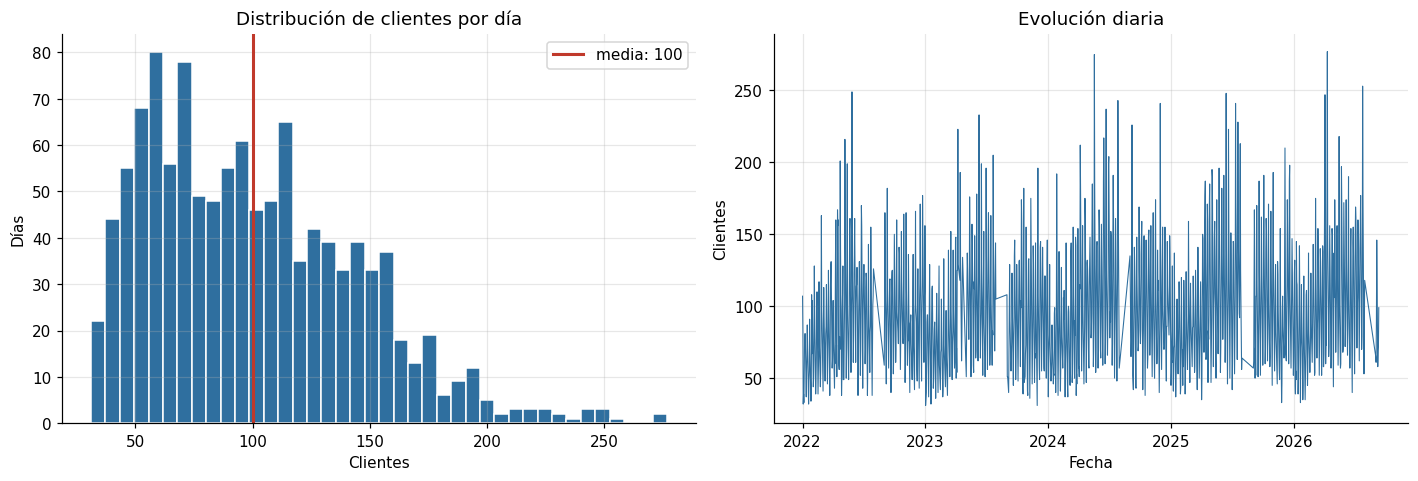

In [15]:
print("CLIENTES POR DÍA")
print("-" * 50)
print(gold["n_clientes"].describe().round(1).to_string())

figura, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

ejes[0].hist(gold["n_clientes"], bins=40, color="#2f6f9f", edgecolor="white")
ejes[0].axvline(gold["n_clientes"].mean(), color="#c0392b", linewidth=2,
                label=f"media: {gold['n_clientes'].mean():.0f}")
ejes[0].set_title("Distribución de clientes por día")
ejes[0].set_xlabel("Clientes")
ejes[0].set_ylabel("Días")
ejes[0].legend()

ejes[1].plot(gold["fecha"], gold["n_clientes"], linewidth=0.7, color="#2f6f9f")
ejes[1].set_title("Evolución diaria")
ejes[1].set_xlabel("Fecha")
ejes[1].set_ylabel("Clientes")

plt.tight_layout()
plt.show()

La distribución tiene dos grupos claros: los días entre semana, en torno a 50-70 clientes, y los fines de semana, muy por encima. No es una campana: es una mezcla de dos poblaciones. Esa separación es exactamente lo que el modelo tiene que aprender.

En la serie temporal se aprecian los huecos de agosto (el restaurante cierra) y una ligera tendencia creciente.

In [16]:
medias_anuales = gold.groupby("año")["n_clientes"].mean()

print("MEDIA DE CLIENTES POR AÑO")
print("-" * 50)

for año, media in medias_anuales.items():
    print(f"  {año}   {media:6.1f} clientes")

crecimiento = 100 * (medias_anuales.iloc[-1] / medias_anuales.iloc[0] - 1)

print()
print(f"Crecimiento acumulado 2022 -> 2026: {crecimiento:+.1f} %")
print()
print("Este crecimiento es importante: ningún modelo de árboles puede")
print("extrapolarlo fuera del rango que ha visto, y será la causa del")
print("sesgo que se analiza en el notebook 04.")

MEDIA DE CLIENTES POR AÑO
--------------------------------------------------
  2022     93.0 clientes
  2023     96.0 clientes
  2024    103.4 clientes
  2025    103.9 clientes
  2026    105.3 clientes

Crecimiento acumulado 2022 -> 2026: +13.2 %

Este crecimiento es importante: ningún modelo de árboles puede
extrapolarlo fuera del rango que ha visto, y será la causa del
sesgo que se analiza en el notebook 04.


## Conclusiones

1. **La meteorología es real y tiene huecos**, que se completan con criterios distintos según la variable: interpolación para las temperaturas y cero para la precipitación inapreciable.

2. **`tmed` es el punto medio de `tmax` y `tmin`.** Las tres columnas solo tienen dos grados de libertad. El modelo usa `tmed` y `amplitud_termica` para evitar una colinealidad que hacía ilegibles los coeficientes.

3. **Los días de cierre se excluyen**, no se cuentan como cero clientes.

4. **La demanda tiene dos poblaciones**: entre semana y fin de semana. Esa es la señal más fuerte del dataset.

5. **El negocio crece un 4 % anual.** Habrá que tenerlo presente al evaluar los modelos.

El siguiente notebook entra en los patrones de demanda.